In [1]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
from scipy import stats
import numpy as np
import glob
import os
import io

from hta.trace_analysis import TraceAnalysis

power_labels = [
    "IBP,",        "ICP,",        "DCP,",      "TCP,",      "CCP,",
    "SHRDP,",      "RFP,",        "INTP,",     "FPUP,",     "DPUP,",
    "INT_MUL24P,", "INT_MUL32P,", "INT_MULP,", "INT_DIVP,", "FP_MULP,",
    "FP_DIVP,",    "FP_SQRTP,",   "FP_LGP,",   "FP_SINP,",  "FP_EXP,",
    "DP_MULP,",    "DP_DIVP,",    "TENSORP,",  "TEXP,",     "SCHEDP,",
    "L2CP,",       "MCP,",        "NOCP,",     "DRAMP,",    "PIPEP,",
    "IDLE_COREP,", "CONSTP",      "STATICP"
]

In [2]:
power_raw_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_power_report.log", 
        has_header=False, 
        separator="?", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*/accelwattch_power_report.log")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
power_raw_df

index,benchmark,data
u32,str,str
0,"""bert""","""kernel_name = _ZN2at6native44_…"
1,"""bert""","""kernel_launch_uid = 1 """
2,"""bert""",null
3,"""bert""","""Kernel Average Power Data:"""
4,"""bert""","""kernel_avg_power = 56.8932"""
…,…,…
1876009,"""resnet50-train""","""gpu_tot_avg_power = 95.5163"""
1876010,"""resnet50-train""","""gpu_tot_max_power = 253.477"""
1876011,"""resnet50-train""","""gpu_tot_min_power = 55.4642"""


In [3]:
power_df = (
    (
        power_raw_df.filter(pl.col("data").str.starts_with("gpu_avg_"))
        .select(
            "index",
            pl.col("data")
            .str.replace("^gpu_avg_", "")
            .str.replace_all(" ", "")
            .str.splitn("=", 2)
            .struct.rename_fields(["label", "value"])
            .struct.with_fields(pl.field("value").cast(float))
            .struct.unnest()
        )
    )
    .join_asof(
        power_raw_df.filter(pl.col("data").str.starts_with("kernel_name"))
        .select(
            pl.col("index"),
            pl.col("index").rank("dense").over("benchmark").alias("serial"),
            pl.col("benchmark"),
            pl.col("data").str.extract("kernel_name = (.*)").alias("kernel")
        ),
        on="index",
    )
    .drop("index")
    .group_by("benchmark", "serial", "kernel", "label").agg(pl.mean("value"))
    .pivot(on="label", index=["benchmark", "serial", "kernel"])
    .select("benchmark", "serial", "kernel", *power_labels)
    .with_columns(
        pl.col("DRAMP,") + pl.col("MCP,"),
        pl.col("L2CP,") + pl.col("NOCP,"),
    )
    .rename(lambda col: col.replace(",", ""))
    .unpivot(index=["benchmark", "serial", "kernel"], value_name="power_w")
    .group_by("benchmark", "serial", "kernel")
    .agg(pl.sum("power_w"))
    .sort("benchmark", "serial", "kernel")
)
power_df

benchmark,serial,kernel,power_w
str,u32,str,f64
"""bert""",1,"""_ZN2at6native44_GLOBAL__N__50c…",57.490228
"""bert""",2,"""_ZN2at6native44_GLOBAL__N__50c…",57.322012
"""bert""",3,"""_ZN2at6native29vectorized_elem…",56.733263
"""bert""",4,"""_ZN2at6native44_GLOBAL__N__50c…",57.496691
"""bert""",5,"""_ZN2at6native29vectorized_elem…",56.42046
…,…,…,…
"""resnet50-train""",941,"""_ZN2at6native57_GLOBAL__N__e65…",69.95192
"""resnet50-train""",942,"""_ZN2at6native54_GLOBAL__N__f8a…",84.832087
"""resnet50-train""",943,"""_ZN2at6native54_GLOBAL__N__f8a…",100.542158


In [4]:
accel_raw_df = (
    pl.scan_csv("/proj/threadtune-PG0/amir/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*",
        has_header=False, 
        separator="&", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)
accel_raw_df

index,benchmark,data
u32,str,str
0,"""bert""","""Skipping setup_environment - a…"
1,"""bert""","""doing: export -n PTX_SIM_USE_P…"
2,"""bert""","""doing: export LD_LIBRARY_PATH=…"
3,"""bert""","""doing: cd /users/zarand1a/acce…"
4,"""bert""","""doing: export OPENCL_CURRENT_T…"
…,…,…
23143917,"""resnet50-train""","""gpgpu_simulation_rate = 230813…"
23143918,"""resnet50-train""","""gpgpu_simulation_rate = 185 (c…"
23143919,"""resnet50-train""","""gpgpu_silicon_slowdown = 61189…"


In [5]:
cycle_df = (
    accel_raw_df.filter(pl.col("data").str.starts_with("kernel_name ="))
    .select(
        "index", "benchmark",
        pl.col("data").str.extract("kernel_name = (.*)").alias("kernel"),
    )
).join(
    accel_raw_df.filter(pl.col("data").str.starts_with("gpu_sim_cycle ="))
    .select(
        pl.col("index") - 3,
        pl.col("data").str.extract("gpu_sim_cycle = (.*)").cast(int).alias("cycle"),
    ),
    on="index",
).select(
    "benchmark",
    pl.col("index").rank("dense").over("benchmark").alias("serial"),
    "kernel", "cycle",
)
cycle_df

benchmark,serial,kernel,cycle
str,u32,str,i64
"""bert""",1,"""_ZN2at6native44_GLOBAL__N__50c…",10376
"""bert""",2,"""_ZN2at6native44_GLOBAL__N__50c…",8566
"""bert""",3,"""_ZN2at6native29vectorized_elem…",5772
"""bert""",4,"""_ZN2at6native44_GLOBAL__N__50c…",10402
"""bert""",5,"""_ZN2at6native29vectorized_elem…",5772
…,…,…,…
"""resnet50-train""",941,"""_ZN2at6native57_GLOBAL__N__e65…",23800
"""resnet50-train""",942,"""_ZN2at6native54_GLOBAL__N__f8a…",50736
"""resnet50-train""",943,"""_ZN2at6native54_GLOBAL__N__f8a…",172263


In [6]:
accel_df = (
    power_df.join(cycle_df, on=["benchmark", "serial", "kernel"])
    .filter(pl.col("power_w").is_not_nan())
    .group_by("benchmark")
    .agg(
        power_w=(pl.col("power_w") * pl.col("cycle")).sum() / pl.col("cycle").sum(),
        cycles=pl.col("cycle").sum()
    )
)
accel_df

benchmark,power_w,cycles
str,f64,i64
"""resnet50""",92.827203,5494692
"""bloom""",112.715731,8252003
"""gemma""",118.201962,25139094
"""deit-train""",97.265104,17660625
"""bloom-train""",111.201916,69053879
…,…,…
"""gpt2""",92.793675,5209931
"""gemma-train""",167.871848,8792586
"""deit""",91.044472,8096467


In [7]:
power_log_raw_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
)
power_log_raw_df

timestamp_ns,total_energy_millijoules,benchmark
i64,i64,str
1364646157625482,59971087531,"""bert"""
1364646257758199,59971092520,"""bert"""
1364646357848963,59971097523,"""bert"""
1364646458912655,59971102673,"""bert"""
1364646559062579,59971107933,"""bert"""
…,…,…
1458527321965226,63909522404,"""resnet50-train"""
1458527422100828,63909529545,"""resnet50-train"""
1458527522249609,63909536871,"""resnet50-train"""


In [8]:
measure_df = (
    power_log_raw_df.with_columns(
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 10000 / 1000
    )
)
measure_df

benchmark,power_w,time_us
str,f64,f64
"""gpt2-train""",89.669436,52817.232234
"""gpt2-inference""",38.570944,22697.103064
"""bloom-train""",129.951943,34904.192136
"""deit-inference""",54.731851,41999.117103
"""bloom-inference""",74.344924,15222.401692
…,…,…
"""deit-train""",68.242799,45746.64186
"""gemma-inference""",107.656783,20228.55822
"""bert-train""",79.030911,53658.204805


In [9]:
comp_df = (
    accel_df.rename({"power_w": "accel_power_W"})
    .with_columns(
        (pl.col("cycles") / 1132).alias("accel_time_us"),
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .drop("cycles")
    .join(
        measure_df.rename({"power_w": "measured_power_W", "time_us": "measured_time_us"}), 
        on="benchmark"
    )
)
comp_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us
str,f64,f64,f64,f64
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064
"""bloom-train""",111.201916,61001.659894,129.951943,34904.192136
"""deit-inference""",91.044472,7152.356007,54.731851,41999.117103
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692
…,…,…,…,…
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186
"""gemma-inference""",118.201962,22207.680212,107.656783,20228.55822
"""bert-train""",106.186118,35501.958481,79.030911,53658.204805


In [10]:
kineto_root = "/proj/threadtune-PG0/amir/kineto_traces/*"
xml_base_path = "/proj/threadtune-PG0/amir/sim_run_12.8"

results = []

for trace_dir in glob.glob(kineto_root):
    full_benchmark_name = os.path.basename(trace_dir)
    
    if "-inference" in full_benchmark_name:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name.replace("-inference", "")
    else:
        benchmark_name = full_benchmark_name
        xml_model_name = full_benchmark_name

    print(f"Processing: {full_benchmark_name} (Cleaned: {benchmark_name})")

    json_path = os.path.join(trace_dir, "device.0.json")
    
    if not os.path.exists(json_path):
        print(f"  Skipping: {json_path} not found.")
        continue

    try:
        kineto_df = (
            pl.read_json(json_path)
            .select(pl.col("traceEvents").explode().struct.unnest())
        )

        total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
        total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

        if total_trace_dur is None: total_trace_dur = 0
        if total_kernel_dur is None: total_kernel_dur = 0
        
        idle_time_us = total_trace_dur - total_kernel_dur

    except Exception as e:
        print(f"  Error reading Kineto trace: {e}")
        continue

    xml_path = f"{xml_base_path}/{xml_model_name}/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_sass_sim.xml"
    
    if not os.path.exists(xml_path):
        print(f"  Warning: XML not found at {xml_path}")
        constant_power = None
        idle_energy = None
    else:
        try:
            xml_df = (
                pl.scan_csv(
                    xml_path, 
                    separator="\x1f", 
                    has_header=False, 
                    new_columns=["line"],
                    quote_char=None
                )
                .filter(pl.col("line").str.contains('name="constant_power"'))
                .select(
                    pl.col("line")
                    .str.extract(r'value="([\d\.]+)"', 1)
                    .cast(pl.Float64)
                )
                .collect()
            )
            
            if xml_df.height > 0:
                constant_power = xml_df.item()
                
                idle_energy = idle_time_us * constant_power
            else:
                constant_power = None
                idle_energy = None
                
        except Exception as e:
            print(f"  Error parsing XML: {e}")
            constant_power = None
            idle_energy = None

    results.append({
        "benchmark": benchmark_name,
        "idle_time_us": idle_time_us,
        "constant_power_W": constant_power,
        "idle_energy_uJ": idle_energy
    })

idle_df = pl.DataFrame(results)
idle_df

Processing: deit-train (Cleaned: deit-train)
Processing: gpt2-inference (Cleaned: gpt2-inference)
Processing: bloom-train (Cleaned: bloom-train)
Processing: resnet50-train (Cleaned: resnet50-train)
Processing: gpt2-train (Cleaned: gpt2-train)
Processing: resnet50-inference (Cleaned: resnet50-inference)
Processing: bert-inference (Cleaned: bert-inference)
Processing: deit-inference (Cleaned: deit-inference)
Processing: bloom-inference (Cleaned: bloom-inference)
Processing: bert-train (Cleaned: bert-train)
Processing: gemma-inference (Cleaned: gemma-inference)


benchmark,idle_time_us,constant_power_W,idle_energy_uJ
str,f64,f64,f64
"""deit-train""",653582.668,32.325223,2.1127e7
"""gpt2-inference""",461579.941,32.325223,1.4921e7
"""bloom-train""",406342.152,32.325223,1.3135e7
"""resnet50-train""",690036.105,32.325223,2.2306e7
"""gpt2-train""",557731.427,32.325223,1.8029e7
…,…,…,…
"""bert-inference""",312991.064,32.325223,1.0118e7
"""deit-inference""",319870.91,32.325223,1.0340e7
"""bloom-inference""",553572.69,32.325223,1.7894e7


In [11]:
main_df = comp_df.join(
    idle_df.select("benchmark", pl.col("constant_power_W").alias("idle_power_W"), "idle_time_us"),
    on="benchmark"
)
main_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us,idle_power_W,idle_time_us
str,f64,f64,f64,f64,f64,f64
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234,32.325223,557731.427
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064,32.325223,461579.941
"""bloom-train""",111.201916,61001.659894,129.951943,34904.192136,32.325223,406342.152
"""deit-inference""",91.044472,7152.356007,54.731851,41999.117103,32.325223,319870.91
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692,32.325223,553572.69
…,…,…,…,…,…,…
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186,32.325223,653582.668
"""gemma-inference""",118.201962,22207.680212,107.656783,20228.55822,32.325223,492388.531
"""bert-train""",106.186118,35501.958481,79.030911,53658.204805,32.325223,631781.294


In [12]:
correct_df = (
    main_df.filter(pl.col("accel_time_us") < pl.col("measured_time_us"))
    .with_columns(
        corrected_power_W = (
            pl.col("accel_power_W") * pl.col("accel_time_us") + 
            (pl.col("measured_time_us") - pl.col("accel_time_us")) * pl.col("idle_power_W")
        ) / (
            pl.col("measured_time_us")
        )
    )
)
correct_df = correct_df.with_columns(
    accel_error = (
        (pl.col("accel_power_W") - pl.col("measured_power_W")) * 100
    ) / (
        pl.col("measured_power_W")
    ),
    corrected_error = (
        abs(pl.col("corrected_power_W") - pl.col("measured_power_W")) * 100
    ) / (
        pl.col("measured_power_W")
    )
)
correct_df

benchmark,accel_power_W,accel_time_us,measured_power_W,measured_time_us,idle_power_W,idle_time_us,corrected_power_W,accel_error,corrected_error
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""gpt2-train""",109.122387,43136.380742,89.669436,52817.232234,32.325223,557731.427,95.046262,21.694071,5.996276
"""gpt2-inference""",92.793675,4602.412544,38.570944,22697.103064,32.325223,461579.941,44.586733,140.579214,15.596685
"""deit-inference""",91.044472,7152.356007,54.731851,41999.117103,32.325223,319870.91,42.32498,66.346417,22.668465
"""bloom-inference""",112.715731,7289.7553,74.344924,15222.401692,32.325223,553572.69,70.822902,51.611872,4.737408
"""bert-inference""",96.99283,2454.583039,59.101363,10755.061665,32.325223,312991.064,47.084042,64.112679,20.333407
"""deit-train""",97.265104,15601.258834,68.242799,45746.64186,32.325223,653582.668,54.47207,42.52801,20.179022
"""bert-train""",106.186118,35501.958481,79.030911,53658.204805,32.325223,631781.294,81.193917,34.360235,2.736912
"""resnet50-inference""",92.827203,4853.968198,54.032302,41119.958221,32.325223,380508.952,39.467124,71.79946,26.956427
"""resnet50-train""",98.370075,21215.730565,70.123221,41214.817838,32.325223,690036.105,66.322457,40.28174,5.420123


In [13]:
correct_df.select(
    pl.min("accel_error").alias("min_accel_error"),
    pl.max("accel_error").alias("max_accel_error"),
    pl.min("corrected_error").alias("min_corrected_error"),
    pl.max("corrected_error").alias("max_corrected_error"),
)


min_accel_error,max_accel_error,min_corrected_error,max_corrected_error
f64,f64,f64,f64
21.694071,140.579214,2.736912,26.956427


In [14]:
dfs = []

for d in [f for f in os.scandir("/proj/threadtune-PG0/amir/kineto_traces/") if f.is_dir()]:
    analyzer = TraceAnalysis({0: "device.0.json"}, d.path)
    sym = analyzer.t.symbol_table.get_sym_table()
    
    dfs.append(pl.concat([
        pl.from_pandas(analyzer.t.get_trace(r)[analyzer.t.get_trace(r)["stream"] != -1][["name", "dur"]])
        for r in analyzer.t.traces
    ]).join(
        pl.from_dict({"name": list(range(len(sym))), "s_name": sym}), on="name"
    ).filter(
        ~pl.col("s_name").str.starts_with("nccl") & 
        ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
    ).select(
        pl.lit(d.name).alias("benchmark"),
        pl.col("dur").sum().alias("measured_kernel_time_sum_us")
    ))

micro_time_measure_df = pl.concat(dfs)
micro_time_measure_df

Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json time = 0.33 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json backend=json in 0.60 seconds; current PID:61957
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json in 0.66 seconds; current PID:61957
leaving parse_multiple_ranks duration=0.67 seconds
leaving parse_traces duration=0.67 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json time = 0.03 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-

benchmark,measured_kernel_time_sum_us
str,f64
"""deit-train""",11432.0
"""gpt2-inference""",2785.0
"""bloom-train""",30633.0
"""resnet50-train""",10838.0
"""gpt2-train""",22947.0
…,…
"""bert-inference""",1601.0
"""deit-inference""",2906.0
"""bloom-inference""",4506.0


In [15]:
df = (
    pl.scan_csv("/proj/threadtune-PG0/amir/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*",
        has_header=False, 
        separator="&", 
        include_file_paths="path",
    )
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*")
        .alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .with_row_index()
    .collect()
)

In [16]:
cycle_df = (
    df.filter(pl.col("data").str.starts_with("kernel_name ="))
    .select(
        "index", "benchmark",
        pl.col("data").str.extract("kernel_name = (.*)").alias("kernel"),
    )
).join(
    df.filter(pl.col("data").str.starts_with("gpu_sim_cycle ="))
    .select(
        pl.col("index") - 3,
        pl.col("data").str.extract("gpu_sim_cycle = (.*)").cast(int).alias("cycle"),
    ),
    on="index",
).select(
    "benchmark",
    pl.col("index").rank("dense").over("benchmark").alias("serial"),
    "kernel", "cycle",
)
accel_sum_time = cycle_df.group_by(
    pl.when(~pl.col("benchmark").str.contains("-train"))
    .then(pl.col("benchmark") + "-inference")
    .otherwise(pl.col("benchmark"))
    .alias("benchmark")
).agg(
    (pl.col("cycle").sum() / 1132).alias("accel_kernel_time_sum_us")
)
accel_sum_time

benchmark,accel_kernel_time_sum_us
str,f64
"""bert-train""",35501.958481
"""gpt2-inference""",4603.500883
"""gpt2-train""",43136.618375
"""gemma-inference""",22209.44258
"""bert-inference""",2454.583039
…,…
"""resnet50-train""",21215.730565
"""deit-train""",15601.258834
"""deit-inference""",7152.356007


In [26]:
micro_time_comp = micro_time_measure_df.join(
    accel_sum_time, 
    on="benchmark"
)
micro_time_comp

benchmark,measured_kernel_time_sum_us,accel_kernel_time_sum_us
str,f64,f64
"""bert-train""",19597.0,35501.958481
"""gpt2-inference""",2785.0,4603.500883
"""gpt2-train""",22947.0,43136.618375
"""gemma-inference""",10994.0,22209.44258
"""bert-inference""",1601.0,2454.583039
…,…,…
"""resnet50-train""",10838.0,21215.730565
"""deit-train""",11432.0,15601.258834
"""deit-inference""",2906.0,7152.356007


In [44]:
plt.rcParams.update({
    "text.usetex": False, "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm", "font.size": 18, "legend.title_fontsize": 16
})

def plot_xy(df, x, y, x_label, y_label, convert_fn=None, legend_loc='lower right', save=False, fig_num=1):
    if convert_fn:
        df = df.with_columns(
            pl.col(x).map_elements(convert_fn, return_dtype=pl.Float64).alias(x),
            pl.col(y).map_elements(convert_fn, return_dtype=pl.Float64).alias(y)
        )

    plot_df = df.with_columns(
        pl.col("benchmark").str.split("-").list.first().alias("model"),
        pl.col("benchmark").str.split("-").list.last().alias("phase")
    )

    models = plot_df["model"].unique().sort().to_list()
    colors = ['#5BB8D7','#57A86B','#A8A857','#6E4587','#ADEBCC','#EBDCAD']
    model_map = {m: c for m, c in zip(models, colors)}
    phase_map = {'inference': 's', 'train': '^'} 

    fig, ax = plt.subplots(figsize=(6, 6))
    
    for (model, phase), data in plot_df.group_by(["model", "phase"]):
        ax.scatter(
            data[x], data[y],
            c=model_map.get(model, 'gray'), marker=phase_map.get(phase, 'o'),
            s=150, edgecolors='black', alpha=0.9, zorder=3
        )

    limit = max(df[x].max(), df[y].max()) * 1.1
    
    ax.plot([0, limit], [0, limit], "gray", ls="--", zorder=1)
    
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_aspect('equal', adjustable='box')
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6)) 
    ax.yaxis.set_major_locator(ticker.MaxNLocator(6))
    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, ls='--', alpha=0.5)

    handles = [mpatches.Patch(color='none', label=r'$\bf{Model}$')] 
    handles += [mpatches.Patch(facecolor=c, edgecolor='k', label=m) for m, c in model_map.items()]
    
    handles += [mpatches.Patch(color='none', label=''), 
                mpatches.Patch(color='none', label=r'$\bf{Phase}$')] 
    handles += [mlines.Line2D([], [], color='w', marker=m, markeredgecolor='k', ms=10, label=p) 
                for p, m in phase_map.items() if p in plot_df["phase"].unique()]

    ax.legend(handles=handles, loc=legend_loc, frameon=True, fontsize=12)
    
    if save:
        plt.savefig(f'Figure_{fig_num}.pdf', bbox_inches='tight')
    else:
        plt.tight_layout()
        plt.show()

/tmp/ipykernel_61957/3518506866.py:9: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("measured_time_us").map_elements(lambda val: ...)
with this one instead:
  + pl.col("measured_time_us") / 1000.0

  pl.col(x).map_elements(convert_fn, return_dtype=pl.Float64).alias(x),
/tmp/ipykernel_61957/3518506866.py:10: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("accel_time_us").map_elements(lambda val: ...)
with this one instead:
  + pl.col("accel_time_us") / 1000.0

  pl.col(y).map_elements(convert_fn, return_dtype=pl.Float64).alias(y)
/tmp/ipykernel_61957/3518506866.py:9: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions AP

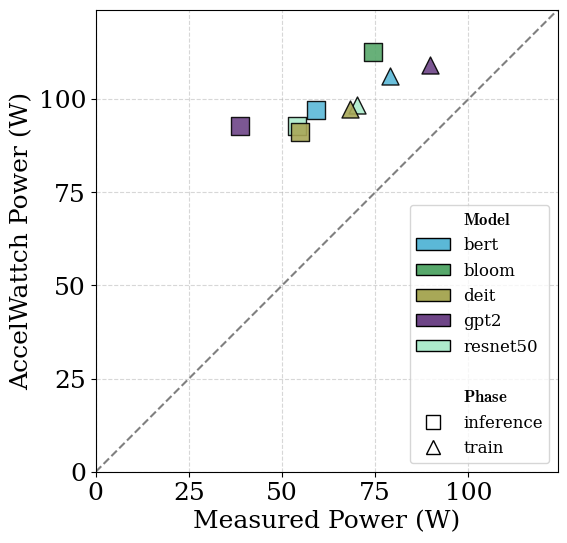

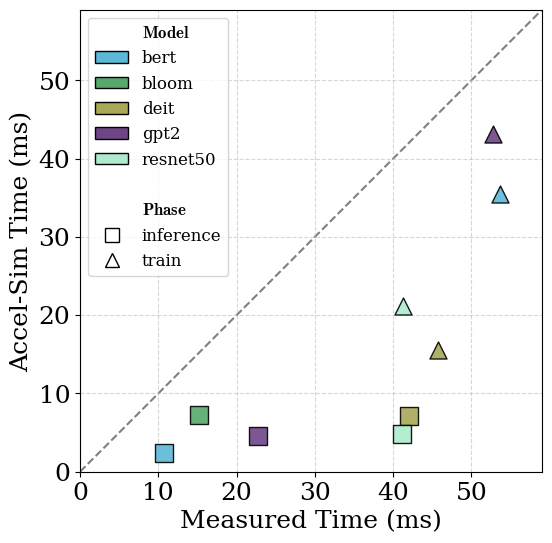

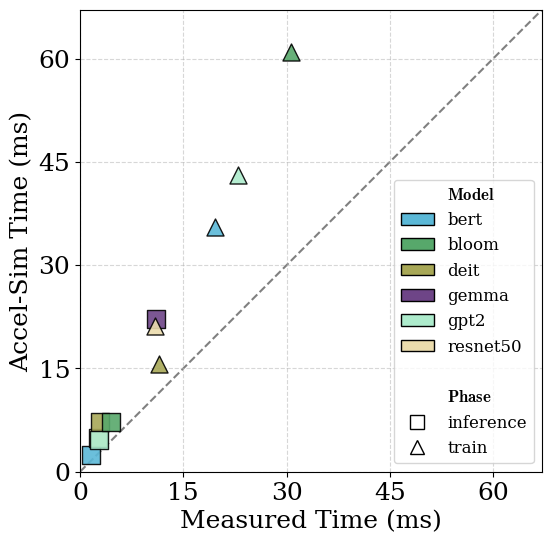

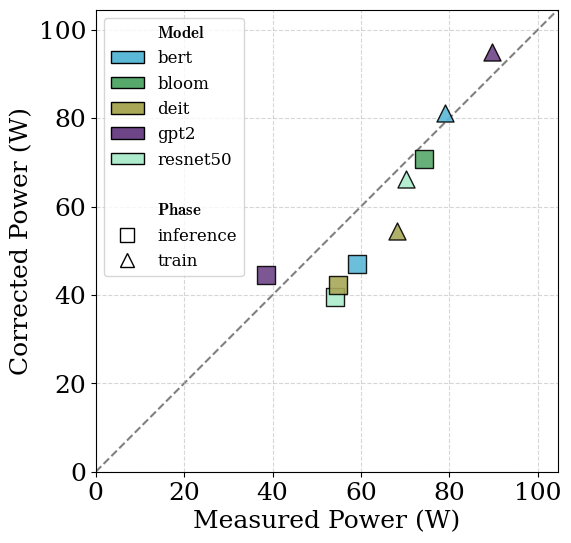

In [ ]:
# plot_xy(
#     correct_df, 
#     'measured_power_W', 
#     'accel_power_W', 
#     "Measured Power (W)", 
#     "AccelWattch Power (W)",
#     save=True,
#     fig_num=1
# )
# plot_xy(
#     correct_df, 
#     'measured_time_us', 
#     'accel_time_us', 
#     "Measured Time (ms)", 
#     "Accel-Sim Time (ms)",
#     convert_fn=lambda val: val / 1000.0,
#     legend_loc="upper left",
#     save=True,
#     fig_num=2
# )
# plot_xy(
#     micro_time_comp, 
#     'measured_kernel_time_sum_us', 
#     'accel_kernel_time_sum_us', 
#     "Measured Time (ms)", 
#     "Accel-Sim Time (ms)",
#     convert_fn=lambda val: val / 1000.0,
#     save=True,
#     fig_num=3
# )
# plot_xy(
#     correct_df, 
#     'measured_power_W', 
#     'corrected_power_W', 
#     "Measured Power (W)", 
#     "Corrected Power (W)",
#     legend_loc="upper left",
#     save=True,
#     fig_num=4
# )

In [ ]:
pdf = final_df.to_pandas()
slope, intercept, r_value, p_value, std_err = stats.linregress(pdf["idle_pct"], pdf["error_w"])